# **Calidad y Limpieza de datos**
Para limpiar el dataset ***solicitudes_credito_neocredit.csv*** se va a utilizar las siguientes librerías:

In [1]:
!pip install pandera ydata-profiling missingno -q
import pandas as pd
import numpy as np
import missingno as msno
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    MinMaxScaler, RobustScaler, MaxAbsScaler, StandardScaler,
    PowerTransformer, Normalizer,
)
import pandera.pandas as pa
from pandera import Column, Check, DataFrameSchema
import matplotlib.pyplot as plt
import seaborn as sns

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 447.8/447.8 kB 22.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.8/400.8 kB 18.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 18.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 73.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 32.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 4.3 MB/s eta 0:00:00


## 1. Perfilado y exploración inicial
subimos el dataset a la nube de google colab e importamos. Observamos que la dimensión de nuestros dataset es de 669 filas y 21 columnas. Además, en un vistazo inicial observamos desde ya que hay columnas con datos faltantes; ya que el total de registros es de 669, pero hay columnas que tienen menos de este valor. Siendo id_solicitud el único campo que tiene todas las columnas.

In [2]:
df = pd.read_csv("/content/solicitudes_credito_neocredit.csv")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 669 entries, 0 to 668
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_solicitud               669 non-null    object 
 1   id_cliente                 663 non-null    object 
 2   nombre_cliente             663 non-null    object 
 3   edad                       663 non-null    float64
 4   genero                     578 non-null    object 
 5   ciudad                     614 non-null    object 
 6   ingreso_mensual            642 non-null    object 
 7   tipo_empleo                607 non-null    object 
 8   antiguedad_laboral_meses   663 non-null    float64
 9   monto_solicitado           663 non-null    float64
 10  plazo_meses                663 non-null    float64
 11  score_buro_externo         635 non-null    float64
 12  deuda_actual               663 non-null    float64
 13  num_tarjetas_activas       663 non-null    float64

Ahora mediante la estadística descriptiva de las columnas numéricas, observamos que existen valores negativos, estos observados en 3 de las 21 variables; lo cual también debemos considerar para nuestra limpieza de datos.

In [4]:
df.describe()

,edad,antiguedad_laboral_meses,monto_solicitado,plazo_meses,score_buro_externo,deuda_actual,num_tarjetas_activas,historial_pagos_atrasados,fraude_flag
count,663.000000,663.000000,663.000000,663.000000,635.000000,663.000000,663.000000,663.000000,663.000000
mean,46.586727,113.235294,3855.039653,36.796380,564.193701,7417.754419,2.963801,1.164404,0.046757
std,18.836343,69.470410,3465.585273,16.874672,183.382834,4385.976062,1.946851,1.161492,0.211278
min,-5.000000,-12.000000,451.930000,12.000000,-1.000000,19.220000,0.000000,0.000000,0.000000
25%,32.000000,56.500000,1040.040000,24.000000,431.000000,3478.785000,1.000000,0.000000,0.000000
50%,47.000000,109.000000,2377.660000,36.000000,575.000000,7584.650000,3.000000,1.000000,0.000000
75%,61.000000,173.000000,5717.945000,48.000000,711.000000,11234.710000,5.000000,2.000000,0.000000
max,210.000000,240.000000,12996.110000,60.000000,950.000000,14971.840000,6.000000,4.000000,1.000000


Podemos observar que los datos faltantes ya están presentes desde nuestros primeros 10 registros.

In [5]:
df.head(10)

,id_solicitud,id_cliente,nombre_cliente,edad,genero,ciudad,ingreso_mensual,tipo_empleo,antiguedad_laboral_meses,monto_solicitado,...,score_buro_externo,deuda_actual,num_tarjetas_activas,historial_pagos_atrasados,fecha_solicitud,canal_solicitud,dispositivo,ip_pais,resultado_solicitud,fraude_flag
0,SOL-10402,CLI-3535,Victor Manuel Eutimio Criado Dávila,39.0,NaN,NaN,1228.2,Empleado,32.0,11846.41,...,655.0,10759.89,3.0,0.0,03/02/2026,Call Center,IOS,Ecuador,Aprobado,0.0
1,SOL-10523,CLI-4482,Francisco Jose Piquer Zamorano,28.0,Femenino,Cuenca,2335.89,Jubilado,82.0,1006.22,...,772.0,6654.80,1.0,3.0,2025-02-20,NaN,IOS,Ecuador,Pendiente,0.0
2,SOL-10425,CLI-4858,Emma Santana Beltran,44.0,Masculino,Ibarra,2190.81,independiente,-12.0,1396.69,...,448.0,14084.54,5.0,3.0,18 de November de 2025,web,Android,Ecuador,Rechazado,0.0
3,SOL-10481,CLI-2144,Urbano Alejo Agullo Martín,67.0,m,quito,1798.58,NaN,148.0,5070.51,...,626.0,629.02,5.0,2.0,2025-08-22,Call Center,IOS,Ecuador,Pendiente,0.0
4,SOL-10301,CLI-3806,Lara Águila-Mendez,25.0,Femenino,quito,1992.73,independiente,237.0,2040.71,...,604.0,13738.36,5.0,3.0,NaN,Call Center,NaN,Rusia,aprobado,1.0
5,SOL-10152,CLI-3432,Manu Hernandez Tamayo,56.0,F,quito,661.73,EMPLEADO,220.0,1950.69,...,546.0,12035.46,4.0,1.0,18 de October de 2025,web,Desconocido,Ecuador,aprobado,0.0
6,SOL-10220,CLI-4013,Ariel Cabrera Salcedo,51.0,F,Manta,3584.76,Independiente,28.0,5230.54,...,628.0,11545.22,1.0,0.0,11-01-2024,NaN,IOS,Ecuador,Rechazado,0.0
7,SOL-10599,CLI-3542,Sebastián Rebollo Valera,48.0,m,Loja,2387.26,NaN,51.0,1924.64,...,423.0,13271.58,4.0,3.0,10-12-2024,APP,iOS,Ecuador,Aprobado,0.0
8,SOL-10530,CLI-2048,María Cristina Almudena Beltran Fabra,69.0,Femenino,Ambato,3227.51,Empleado,155.0,1873.09,...,365.0,4541.41,1.0,0.0,2026-02-11,NaN,android,Ecuador,Pendiente,0.0
9,SOL-10545,CLI-1859,Miguela de Zamora,73.0,m,Loja,2931.98,independiente,44.0,12861.20,...,673.0,2435.61,3.0,0.0,27/07/2024,Call Center,Desconocido,Ecuador,RECHAZADO,0.0


## 2. Detección de columnas irrelevantes
Antes de pasar al proceso del tratamiento con datos nulos, debemos observar si nuestro dataset tiene columnas irrelevantes. Para ello haremos conteo de cuantos subniveles (registros diferentes tiene cada columna). Se debe eliminar columnas que tengan menos de 2 subniveles, ya que al tener solo un mismo valor en todo no aporta nada al dataset para procesos de análisis. Para este dataset, observamos que todas las columnas tienen mas de 1 subnivel, por tanto todas son relevantes tomando en cuenta este aspecto.


In [6]:
df_columnas = df.columns.tolist()
for col in df_columnas:
  print(f'Columna {col}: {df[col].nunique()} subniveles')

Columna id_solicitud: 656 subniveles
Columna id_cliente: 529 subniveles
Columna nombre_cliente: 560 subniveles
Columna edad: 63 subniveles
Columna genero: 7 subniveles
Columna ciudad: 12 subniveles
Columna ingreso_mensual: 610 subniveles
Columna tipo_empleo: 8 subniveles
Columna antiguedad_laboral_meses: 223 subniveles
Columna monto_solicitado: 650 subniveles
Columna plazo_meses: 5 subniveles
Columna score_buro_externo: 376 subniveles
Columna deuda_actual: 650 subniveles
Columna num_tarjetas_activas: 7 subniveles
Columna historial_pagos_atrasados: 5 subniveles
Columna fecha_solicitud: 505 subniveles
Columna canal_solicitud: 7 subniveles
Columna dispositivo: 6 subniveles
Columna ip_pais: 7 subniveles
Columna resultado_solicitud: 5 subniveles
Columna fraude_flag: 2 subniveles


Se puede tomar la primera columna como irrelevente, ya que solo representa un código de transacción generado, aunque si observamos detalladamente, el total de registros distintos es 669, pero la columna id_solicitud tiene 656 subniveles distintos, es decir, hay solicitudes procesadas nuevamente. Sin embargo, concluimos que no estarían sumando algo importante para un posterior análisis, por tanto esta se eliminará, quedandonos con 20 columnas.

Hay otras columnas que a consideración nuestra podría tomarse como irreleventaes: nombre, genero, ciudad y fecha_solicitud; pero al no ser expertos en temas de créditos y como esto pdría sumar o no para un análisis posterior a la limpieza de datos, se obtó por dejar todas las columnas.

In [7]:
df_i2 = df.iloc[:, 1:len(df.columns)]
df_i2.shape

(669, 20)

## 3. Tratamiento de datos faltantes
Antes de pasar a nuestro filtrado de datos faltantes, observamos mediante un conteo cuantos valores Nulos hay presentes por cada campo del dataset. Para esto usaremos la librería matplotlib para representar estos valores de manera gráfica y permita tener un mejor detalle de la cantidad de nulos.

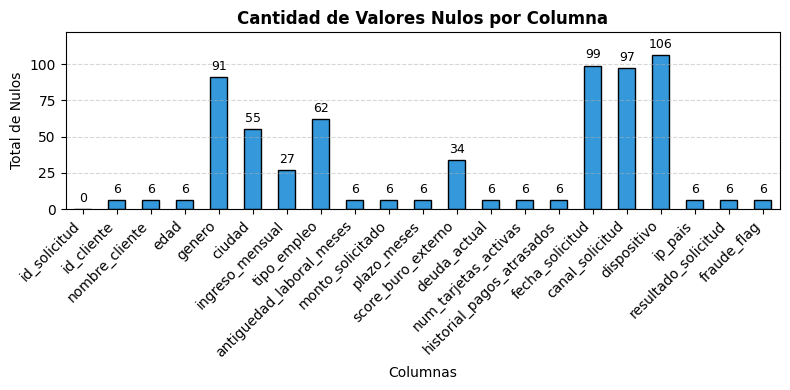

In [8]:
import matplotlib.pyplot as plt

nulos = df.isnull().sum() #Obtener nulos
plt.figure(figsize=(8, 4)) #Crear figura
ax = nulos.plot(kind="bar", color="#3498db", edgecolor="black") #Guardar el gráfico en la variable 'ax'
ax.bar_label(ax.containers[0], padding=3, fontsize=9) #Agregar el conteo en cada barra
plt.title("Cantidad de Valores Nulos por Columna", fontsize=12, fontweight="bold") #Personalización de ejes y título
plt.xlabel("Columnas")
plt.ylabel("Total de Nulos")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.ylim(0, nulos.max() * 1.15) #Dar un poco más de espacio arriba para que el número no toque el borde del gráfico
plt.tight_layout()
plt.show()

Al igual que el gráfico anterior obtuvimos el total de registros nulos por columnas, tambien observaremos en el gráfico a continuación cuanto representa en porcentaje esos nulos en nuestro dataset. Con esto, podremos tener un análisis inicial del impacto de los datos faltantes en nuestro dataset.

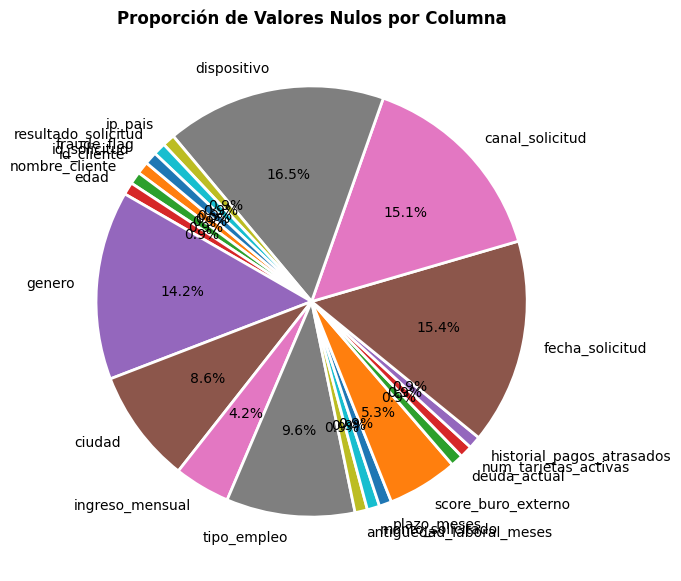

In [9]:
plt.figure(figsize=(7, 7))
plt.pie(#Generar el gráfico de pastel con porcentajes
    nulos,
    labels=nulos.index, #Nombres de las columnas
    autopct="%1.1f%%", #Muestra solo el porcentaje
    startangle=140,
    wedgeprops={"edgecolor": "white", "linewidth": 2})
plt.title("Proporción de Valores Nulos por Columna", fontsize=12, fontweight="bold")
plt.show()

Hemos analizado las cantidades y procentajes de valores nulos presentes por columna en el dataset pero, tambien debemos observar el porcentaje representado por fila, siendo este mas grande aún, siperando el 50% del total del dataset, más de la mitad almenos tiene un valor nulo en cada fila. Esto nos da a entender definitivamente que no se debe realizar la eliminación de los valores faltantes. Para este caso debemos aplicar tecnicas de imputación de datos.

In [10]:
print(f"El porcentaje de nulos por fila es: {(((df.isna().any(axis=1).sum()) / len(df)) * 100).round(2)}%")


El porcentaje de nulos por fila es: 58.15%


## 4. Imputación de datos numéricos
Como se explicó en la sección anterior; no se realizó la eliminación de datos faltantes debido a que representaban un alto porcentaje tanto para filas como sus columnas. Se realizará el proceso de imputación de datos mediante la mediana en cada columna. Pero, en primer lugar debemos realizar la evaluación de los tipos de datos sean correctos, acorde a lo esperado por la columna. Observamos algunas como ingreso_mensual que debería ser numérica pero esta como tipo objeto. Estas conversiones se realizarán para los datos numéricos.

Los casos como la edad, plazo_meses, antiguedad_laboral_meses y otros mas ya están como numéricos float, pero sabemos que las edades o meses no se representan como decimales, por ello se transformará a entero. Adicional, se ha detectado que hay valores de tipo texto en las columnas de tipo numérico, esto se da debido que tiene valores con signos como el $, se hará la eliminación y transformación de esos valores.

In [19]:
df_i2_i4 = df_i2.copy()

columnas = ['edad', 'antiguedad_laboral_meses', 'plazo_meses', 'num_tarjetas_activas', 'historial_pagos_atrasados', 'fraude_flag']  #a enteros
for col in columnas:
  df_i2_i4[col] = df_i2_i4[col].astype(str).str.replace(r'[\$]', '', regex=True)
  df_i2_i4[col] = pd.to_numeric(df_i2_i4[col], errors='coerce').astype('Int64')

columnas = ['ingreso_mensual', 'monto_solicitado', 'score_buro_externo', 'deuda_actual']  #a decimales
for col in columnas:
  df_i2_i4[col] = df_i2_i4[col].astype(str).str.replace(r'[\$]', '', regex=True)
  df_i2_i4[col] = pd.to_numeric(df_i2_i4[col], errors='coerce')

Despues de realizar la conversión de los tipos de datos, mendiante la función info() comprobamos los cambios efectuados correctamente.

In [12]:
df_i2_i4.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 669 entries, 0 to 668
Data columns (total 20 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 663 non-null    object 
 1   nombre_cliente             663 non-null    object 
 2   edad                       663 non-null    Int64  
 3   genero                     578 non-null    object 
 4   ciudad                     614 non-null    object 
 5   ingreso_mensual            586 non-null    float64
 6   tipo_empleo                607 non-null    object 
 7   antiguedad_laboral_meses   663 non-null    Int64  
 8   monto_solicitado           663 non-null    float64
 9   plazo_meses                663 non-null    Int64  
 10  score_buro_externo         635 non-null    float64
 11  deuda_actual               663 non-null    float64
 12  num_tarjetas_activas       663 non-null    Int64  
 13  historial_pagos_atrasados  663 non-null    Int64  

Ahora procederemos con la imputación de datos por cada columna, para realizar este proceso se ha obtado por rellenar esos "huecos" con la mediana de cada columna; ¿Porqué este método y no usar el método de relleno hacia atras (bfill)? En la práctica y acorde a investigaciones, este método se emplea mas para series o datos ordenados, como nuestro conjunto de datos no tiene secuencias en sus columnas o información que sea serializada no es conveniente aplicar este método. Por ello, harémos uso de la estrategia de imputación con la mediana utilizando el método SimpleImputer.

Primer seleccionamos las filas que son numéricas para realizar el proceso mencionado anteriormente.

In [29]:
columnas = ['edad', 'ingreso_mensual', 'antiguedad_laboral_meses', 'monto_solicitado', 'plazo_meses', #numericas
            'score_buro_externo', 'deuda_actual', 'num_tarjetas_activas', 'historial_pagos_atrasados', 'fraude_flag']
imputer = SimpleImputer(strategy="median")
for col in columnas:
  df_i2_i4[col] = imputer.fit_transform(df_i2_i4[[col]])

## 5. Erróres tipográficos
Para verificar errores tipográficos en variables categóricas, debemos observar los subniveles de cada columna para validar si se pueden hacer correciones. Como ejemplo, tenemos la columna genero; esta solamente registra 2 generos: Masculino y Femenino, sin embargo, en el datset hay abreviaturas y en mayusculas o minusculas, dando esto mas subniveles que representan los mismos.

Se realizará una reducción de subniveles que sean igual o que esten tipados erroeamente. Primero realizaremos este proceso en las varaibles categóricas. No se toma en cuenta: id_cliente, nombre_cliente y fecha_solicitud debido que son valores que no son categorizados.

In [50]:
#columnas = ['id_cliente', 'nombre_cliente', 'genero', 'ciudad', 'tipo_empleo', #categoricas
#             'fecha_solicitud', 'canal_solicitud', 'dispositivo', 'ip_pais', 'resultado_solicitud']
df_i2_i4_i5 = df_i2_i4.copy()
print(f"La columna genero tiene: {df_i2_i4['genero'].unique()}")
print(f"La columna ciudad tiene: {df_i2_i4['ciudad'].unique()}")
print(f"La columna tipo_empleo tiene: {df_i2_i4['tipo_empleo'].unique()}")
print(f"La columna canal_solicitud tiene: {df_i2_i4['canal_solicitud'].unique()}")
print(f"La columna dispositivo tiene: {df_i2_i4['dispositivo'].unique()}")
print(f"La columna ip_pais tiene: {df_i2_i4['ip_pais'].unique()}")
print(f"La columna resultado_solicitud tiene: {df_i2_i4['resultado_solicitud'].unique()}")

La columna genero tiene: [nan 'Femenino' 'Masculino' 'm' 'F' 'f' 'Otro' 'M']
La columna ciudad tiene: [nan 'Cuenca' 'Ibarra' 'quito' 'Manta' 'Loja' 'Ambato' 'Quito' 'Guayaquil'
 'GUAYAQUIL' 'Machala' 'Sto. Domingo' 'Cuenca ']
La columna tipo_empleo tiene: ['Empleado' 'Jubilado' 'independiente' nan 'EMPLEADO' 'Independiente'
 'estudiante' 'empleado' 'Desempleado']
La columna canal_solicitud tiene: ['Call Center' nan 'web' 'APP' 'app movil' 'Sucursal' 'App' 'Web']
La columna dispositivo tiene: ['IOS' 'Android' nan 'Desconocido' 'iOS' 'android' 'Desktop']
La columna ip_pais tiene: ['Ecuador' 'Rusia' 'Colombia' 'Peru' nan 'Ecuador (VPN)' 'Nigeria'
 'Vietnam']
La columna resultado_solicitud tiene: ['Aprobado' 'Pendiente' 'Rechazado' 'aprobado' 'RECHAZADO' nan]


Como se observa en el resultado anterior, en cada columna existen categorías que se repiten de diferente forma, vamos a hacer la unificación de subniveles. Para este caso práctico, al haber categorías que sin iguales pero se diferencias en mayusculas o minusculas, se consideró dejar todos los valores en minusculas. Con esto podemos reducir el numero de categrorías en las columnas.

In [51]:
columnas = ['genero', 'ciudad', 'tipo_empleo', 'canal_solicitud', 'dispositivo', 'ip_pais', 'resultado_solicitud']
for col in columnas:
  df_i2_i4_i5[col] = df_i2_i4_i5[col].str.lower()

In [55]:
print(f"La columna genero tiene: {df_i2_i4_i5['genero'].unique()}")
print(f"La columna ciudad tiene: {df_i2_i4_i5['ciudad'].unique()}")
print(f"La columna tipo_empleo tiene: {df_i2_i4_i5['tipo_empleo'].unique()}")
print(f"La columna canal_solicitud tiene: {df_i2_i4_i5['canal_solicitud'].unique()}")
print(f"La columna dispositivo tiene: {df_i2_i4_i5['dispositivo'].unique()}")
print(f"La columna ip_pais tiene: {df_i2_i4_i5['ip_pais'].unique()}")
print(f"La columna resultado_solicitud tiene: {df_i2_i4_i5['resultado_solicitud'].unique()}")

La columna genero tiene: [nan 'femenino' 'masculino' 'otro']
La columna ciudad tiene: [nan 'cuenca' 'ibarra' 'quito' 'manta' 'loja' 'ambato' 'guayaquil'
 'machala' 'sto. domingo']
La columna tipo_empleo tiene: ['empleado' 'jubilado' 'independiente' nan 'estudiante' 'desempleado']
La columna canal_solicitud tiene: ['call center' nan 'web' 'app' 'sucursal']
La columna dispositivo tiene: ['ios' 'android' nan 'desconocido' 'desktop']
La columna ip_pais tiene: ['ecuador' 'rusia' 'colombia' 'peru' nan 'ecuador (vpn)' 'nigeria'
 'vietnam']
La columna resultado_solicitud tiene: ['aprobado' 'pendiente' 'rechazado' nan]


Ahora observamos que en la columna ciudad, hay una categoría que tiene espacios al final, vamos a aplicar a todas las columnas la eliminación de espacios al inicio y al final; además con esto bajamos los subniveles de las columnas.

In [53]:
for col in columnas:
  df_i2_i4_i5[col] = df_i2_i4_i5[col].str.strip()

Como último paso, modificamos los subniveles por columna con el fin de reducir y unificarlos. En este caso solamente aplicamos en la columna genero y canal_solicitud ya que es la que mas presentan subniveles repetidos.

In [54]:
df_i2_i4_i5.loc[df_i2_i4_i5['genero'] == 'm', 'genero'] = 'masculino'
df_i2_i4_i5.loc[df_i2_i4_i5['genero'] == 'f', 'genero'] = 'femenino'
df_i2_i4_i5.loc[df_i2_i4_i5['canal_solicitud'] == 'app movil', 'canal_solicitud'] = 'app'

Como vimos en el item del perfilado de datos, observamos que existen datos en las columnas numéricas como negativos, esto puede considerarse como un error tipofráfico, ¿Porqué lo consideramos así? en las columnas en la que se vio estos datos son: edad, ingreso_mensual y antiguedad_laboral_mes, se analiza y realmente se puede notar que son variables que no pueden ser negativas ya que no se puede tener una edad negativa, nadie tampoco gana en menos, el tiempo en meses no es negativo. El único campo que consideramos dejara en negativo es el score_buro_externo debido que no sabemos como es la logica de la entidad para clasificar el buro de solicitante, por tanto se dejan los valores negativos presentes (En entornos normales no deberían existir). Pero analizando un poco, realizamos el conteo de los diferentes valores negativos en esta columna y se observo que solo hay un valor presente en varios registros, por tanto es un valor asignado por la misma entidad para clasificar a sus solicitantes.

In [57]:
df_i2_i4_i5[df_i2_i4_i5['score_buro_externo'] < 0]['score_buro_externo'].value_counts()

,count
score_buro_externo,
-10.0,8


Realizamos la transformación de valores negativos en las 3 columnas mencionadas.

In [59]:
df_i2_i4_i5['edad'] = df_i2_i4_i5['edad'].abs()
df_i2_i4_i5['ingreso_mensual'] = df_i2_i4_i5['ingreso_mensual'].abs()
df_i2_i4_i5['antiguedad_laboral_meses'] = df_i2_i4_i5['antiguedad_laboral_meses'].abs()
df_i2_i4_i5.describe()

## 6. Imputación de datos categóricos
Para este proceso se toma en consideración el porcentaje de valores nulos presentes en cada columna categórica, ya que no se aplica el mismo proceso que en las varibales numéricas. Para ello hemos condierado que; Si el porcentaje de Nan es menor al 5% se usará la moda para llenar los espacios vacíos. Si el porcentaje de Nan es mayor al 5% se llenará con la categoría "desconocido".

Tomando eso en cuenta, y basandonos en el gráfico de pastel del porcentaje de nulos presentes, las columnas categóricas que se imputarán con la moda son:

*   id_cliente
*   nombre_cliente
*   id_pais
*   resultado_solicitud

Y las columnas que se imputará con la categoría "desconocido" son:

*   genero
*   ciudad
*   tipo_empleo
*   fecha_solicitud
*   canal_solicitud
*   dispositivo



In [61]:
df_i2_i4_i5_i6 = df_i2_i4_i5.copy()
columnas = ['id_cliente', 'nombre_cliente', 'ip_pais', 'resultado_solicitud']
for col in columnas:
  moda = df_i2_i4_i5_i6[col].mode()[0]
  df_i2_i4_i5_i6[col] = df_i2_i4_i5_i6[col].fillna(moda)

In [62]:
columnas = ['genero', 'ciudad', 'tipo_empleo', 'fecha_solicitud', 'canal_solicitud', 'dispositivo']
for col in columnas:
  df_i2_i4_i5_i6[col] = df_i2_i4_i5_i6[col].fillna('desconocido')

Al realizar el último proceso de imputación observamos con la funcuón info() que los datos en su totalidad en cada columna están completos.

In [65]:
df_i2_i4_i5_i6.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 669 entries, 0 to 668
Data columns (total 20 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 669 non-null    object 
 1   nombre_cliente             669 non-null    object 
 2   edad                       669 non-null    float64
 3   genero                     669 non-null    object 
 4   ciudad                     669 non-null    object 
 5   ingreso_mensual            669 non-null    float64
 6   tipo_empleo                669 non-null    object 
 7   antiguedad_laboral_meses   669 non-null    float64
 8   monto_solicitado           669 non-null    float64
 9   plazo_meses                669 non-null    float64
 10  score_buro_externo         669 non-null    float64
 11  deuda_actual               669 non-null    float64
 12  num_tarjetas_activas       669 non-null    float64
 13  historial_pagos_atrasados  669 non-null    float64

## 7. Escalado y normalización
Para el escalado de los datos se optó por el método de escalado robusto (RobustScaler) ya que nuestros datos tienen valores atípicos que si usamos el escalado estandar (MinMaxScaler) puede verse afectado la proporción de los valores.

In [66]:
df_i2_i4_i5_i6_i7 = df_i2_i4_i5_i6.copy()
columnas = ['edad', 'ingreso_mensual', 'antiguedad_laboral_meses', 'monto_solicitado', 'plazo_meses', #numericas
            'score_buro_externo', 'deuda_actual', 'num_tarjetas_activas', 'historial_pagos_atrasados']
robust_scaler = RobustScaler()
for col in columnas:
  df_i2_i4_i5_i6_i7[col + "robust_scaler"] = robust_scaler.fit_transform(df_i2_i4_i5_i6_i7[[col]])

Para la normalización, se optó por utilizar los 2 métodos enseñados en clases mediante los talleres, para que sea de prática y al final quede un dataset resultante con todas las variantes para aplicar al análsis de datos posterior al proceso de calidad y limpieza de datos.

In [74]:
pt = PowerTransformer(method="yeo-johnson")
l2_normalizer = Normalizer(norm="l2")
for col in columnas:
  df_i2_i4_i5_i6_i7[col + "yeo_norm"] = pt.fit_transform(df_i2_i4_i5_i6_i7[[col]])
  df_i2_i4_i5_i6_i7[col + "l2_norm"] = l2_normalizer.fit_transform(df_i2_i4_i5_i6_i7[[col]])

## 8. Definición de reglas de calidad de los datos
Como punto final, validamos manualmente con reglas de calidad de los datos, comproando si el resultado final cumple con los esperados en cada columna; como el tipo de datos esperado, si hay nulos, valores únicos y algunas reglas de negocio. Validamos que el resultado final cumple con los requisitos esperados.

In [81]:
import pandera.pandas as pa
schema = DataFrameSchema(
    columns={
        "id_cliente": Column(
            str,
            Check.str_matches(r"^CLI-\d+$"),
            nullable=False,
            unique=True,
        ),
        "nombre_cliente": Column(
            str,
            Check.str_length(
                min_value=2, max_value=100
            ),
            nullable=True,
        ),
        "edad": Column(
            float,
            Check.between(0, 210),
            nullable=True,
        ),
        "genero": Column(
            str,
            # Lista cerrada de opciones válidas
            Check.isin(["masculino", "femenino", "otro", "desconocido"]),
            nullable=True,
        ),
        "ciudad": Column(
            str,
            Check.str_length(min_value=2),
            nullable=True,
        ),
        # 3. Información Laboral y Financiera
        "ingreso_mensual": Column(
            float,
            Check.ge(0),  # Mayor o igual a cero
            nullable=True,
        ),
        "tipo_empleo": Column(
            str,
            Check.isin(
                ['empleado', 'jubilado', 'independiente','estudiante','desempleado','desconocido']
            ),
            nullable=True,
        ),
        "antiguedad_laboral_meses": Column(
            float,
            Check.between(0, 10000),  # Máximo 50 años de antigüedad laboral
            nullable=True,
        ),
        # 4. Comportamiento Crediticio (Buró)
        "score_buro_externo": Column(
            float,
            # Típico rango de score crediticio (ej. 300 a 850 ó 1 a 1000)
            Check.between(-10, 850),
            nullable=True,
        ),
        "deuda_actual": Column(
            float,
            Check.ge(0),
            nullable=True,
        ),
        "num_tarjetas_activas": Column(
            float,
            Check.between(0, 25),  # Límite lógico de tarjetas por persona
            nullable=True,
        ),
        "historial_pagos_atrasados": Column(
            float,
            Check.ge(0),  # Conteo de moras
            nullable=True,
        ),
        # 5. Datos de la Solicitud y Canal
        "fecha_solicitud": Column(
            # Convertir la columna a datetime en Pandas o validarla como formato ISO
            str,
            Check.str_matches(
                r"^\d{4}-\d{2}-\d{2}"
            ),  # Garantiza formato YYYY-MM-DD
            nullable=True,
        ),
        "canal_solicitud": Column(
            str,
            Check.isin(['call center', 'web', 'app', 'sucursal', 'desconocido']),
            nullable=True,
        ),
        "dispositivo": Column(
            str,
            Check.isin(['ios', 'android','desconocido', 'desktop']),
            nullable=True,
        ),
        "ip_pais": Column(
            str,
            Check.str_length(min_value=2),
            nullable=True,
        ),
        # 6. Resultados y Fraude
        "resultado_solicitud": Column(
            str,
            Check.isin(['aprobado', 'pendiente', 'rechazado']),
            nullable=True,
        ),
        "fraude_flag": Column(
            float,
            # Al ser un indicador (flag), solo debe tomar valores 0 (No) o 1 (Sí)
            Check.isin([0.0, 1.0]),
            nullable=True,
        ),
    },
    # Regla de coherencia cruzada
    checks=[
        # Un desempleado no debería tener 20 años de antigüedad laboral activa
        Check(
            lambda df: ~(
                (df["tipo_empleo"] == "Desempleado")
                & (df["antiguedad_laboral_meses"] > 0)
            ),
            name="check_coherencia_desempleado_antiguedad",
        )
    ],
)
try:
 schema.validate(df_i2_i4_i5_i6_i7, lazy=True)
 print("El dataset cumple con las reglas de calidad definidas.")
except pa.errors.SchemaErrors as err:
 print(err.failure_cases)

     schema_context              column                              check  \
0            Column          id_cliente                   field_uniqueness   
930          Column     fecha_solicitud  str_matches('^\d{4}-\d{2}-\d{2}')   
938          Column     fecha_solicitud  str_matches('^\d{4}-\d{2}-\d{2}')   
937          Column     fecha_solicitud  str_matches('^\d{4}-\d{2}-\d{2}')   
936          Column     fecha_solicitud  str_matches('^\d{4}-\d{2}-\d{2}')   
...             ...                 ...                                ...   
465          Column  score_buro_externo                 in_range(-10, 850)   
464          Column  score_buro_externo                 in_range(-10, 850)   
463          Column  score_buro_externo                 in_range(-10, 850)   
462          Column  score_buro_externo                 in_range(-10, 850)   
1398         Column     fecha_solicitud  str_matches('^\d{4}-\d{2}-\d{2}')   

     check_number           failure_case  index  
0            

,edad,ingreso_mensual,antiguedad_laboral_meses,monto_solicitado,plazo_meses,score_buro_externo,deuda_actual,num_tarjetas_activas,historial_pagos_atrasados,fraude_flag,...,plazo_mesesyeo_norm,plazo_mesesl2_norm,score_buro_externoyeo_norm,score_buro_externol2_norm,deuda_actualyeo_norm,deuda_actuall2_norm,num_tarjetas_activasyeo_norm,num_tarjetas_activasl2_norm,historial_pagos_atrasadosyeo_norm,historial_pagos_atrasadosl2_norm
count,669.000000,6.690000e+02,669.000000,6.690000e+02,669.000000,669.000000,6.690000e+02,669.000000,669.000000,669.000000,...,6.690000e+02,669.0,6.690000e+02,669.000000,6.690000e+02,669.0,6.690000e+02,669.000000,6.690000e+02,669.000000
mean,46.650224,2.241853e+06,113.699552,3.461898e+05,36.789238,5647.428999,6.776754e+05,2.964126,1.162930,0.046338,...,-1.586507e-16,1.0,2.389718e-16,0.964126,-3.292500e-16,1.0,-2.681794e-16,0.868460,1.991431e-16,0.618834
std,18.602128,1.242710e+06,68.328773,3.413799e+05,16.798884,1786.707480,4.597608e+05,1.938091,1.156368,0.210373,...,1.000748e+00,0.0,1.000748e+00,0.242056,1.000748e+00,0.0,1.000748e+00,0.338242,1.000748e+00,0.486037
min,0.000000,5.869000e+04,0.000000,5.317000e+03,12.000000,-10.000000,1.773000e+03,0.000000,0.000000,0.000000,...,-1.540677e+00,1.0,-3.228539e+00,-1.000000,-2.075969e+00,1.0,-1.645427e+00,0.000000,-1.154978e+00,0.000000
25%,32.000000,1.308350e+06,57.000000,9.299500e+04,24.000000,4400.000000,2.312020e+05,1.000000,0.000000,0.000000,...,-7.243014e-01,1.0,-6.914395e-01,1.000000,-8.767928e-01,1.0,-9.937314e-01,1.000000,-1.154978e+00,0.000000
50%,47.000000,2.199075e+06,109.000000,1.968030e+05,36.000000,5750.000000,6.676670e+05,3.000000,1.000000,0.000000,...,6.830106e-03,1.0,6.215372e-02,1.000000,1.612939e-01,1.0,8.972016e-02,1.000000,1.590477e-01,1.000000
75%,61.000000,3.258510e+06,173.000000,5.260070e+05,48.000000,7070.000000,1.087484e+06,5.000000,2.000000,0.000000,...,6.867732e-01,1.0,7.945702e-01,1.000000,8.888811e-01,1.0,1.031225e+00,1.000000,8.765503e-01,1.000000
max,210.000000,4.498250e+06,240.000000,1.299611e+06,60.000000,9500.000000,1.497184e+06,6.000000,4.000000,1.000000,...,1.330764e+00,1.0,2.134089e+00,1.000000,1.485380e+00,1.0,1.469316e+00,1.000000,1.730239e+00,1.000000


## 8. Exportación del dataset limpio
Una vez aplicada las ténicas de calidad y limpieza de datos, podemos exportar el dataframe en un nuevo archivo .csv para que pueda ser utilizado en nuevos proceso de análisis de dstos.

In [82]:
ruta = '/content/neo_credit_clean.csv'
df_i2_i4_i5_i6_i7.to_csv(ruta,index=False)